### Loading of dataset

dataset used: https://www.web-of-life.es/map.php?type=7
This dataset is from the web-of-life website. We are using the marine food web of the Carribean

how is hierarchical structure produced?
1. remove cannibalism logic (self loops)

2. collapse cycles so if there is a cycle formed (A -> B -> C -> A) it will have the same tier

3. start from basal species where there are no incoming edges, they are assigned level = 0

4. computing trophic levels

    a. allow same level feeding

    b. only feed from the tiers below (default)

Code below shows the graph where animals in each tier either eat the animals in the same tier (when they form a feeding cycle) or the animals in the tiers lower and never in the higher tiers

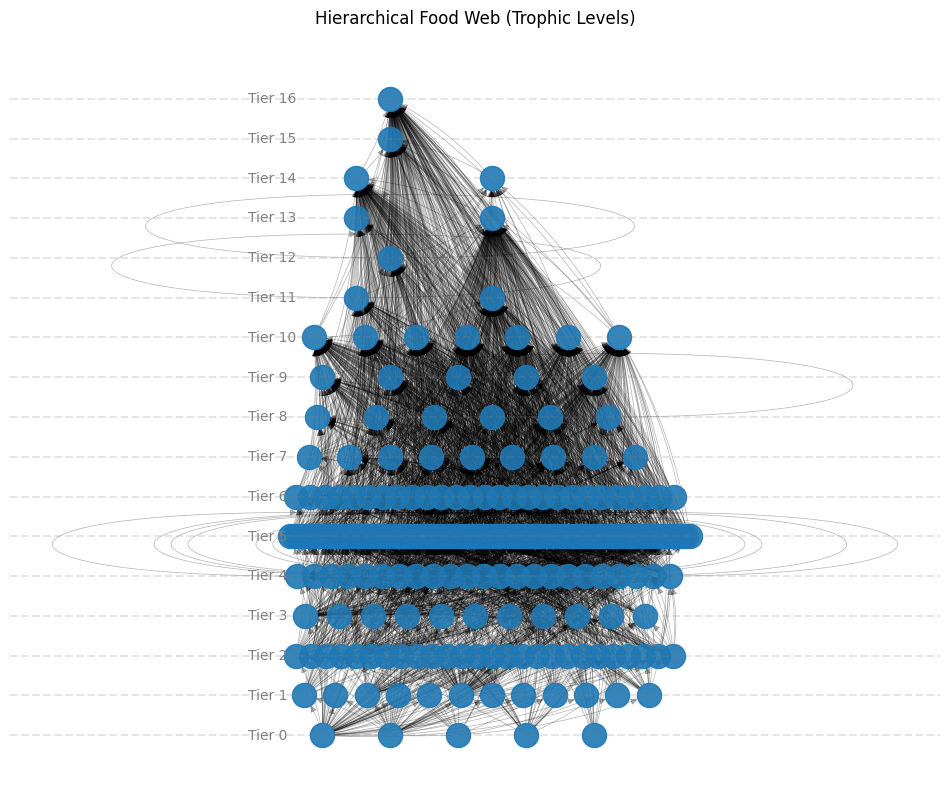

Nodes: 249
Edges: 3313
Violations: 0


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


# -----------------------------
# 1. Load data
# -----------------------------
df = pd.read_csv('data/FW_008.csv', index_col=0)

G = nx.DiGraph()

adj_matrix = df.values
prey_nodes = df.index.tolist()
predator_nodes = df.columns.tolist()

rows, cols = np.where(adj_matrix > 0)
edges = [(prey_nodes[r], predator_nodes[c]) for r, c in zip(rows, cols)]
G.add_edges_from(edges)


# -----------------------------
# 2. Compute trophic levels
# -----------------------------
def compute_trophic_levels(G, allow_same_level=False):
    """
    Computes hierarchical levels such that:
    - edges go from prey -> predator
    - predator level >= prey level
    """

    # Step 1: remove self-loops
    G_clean = G.copy()
    G_clean.remove_edges_from(nx.selfloop_edges(G_clean))

    # Step 2: collapse strongly connected components (cycles)
    scc = list(nx.strongly_connected_components(G_clean))
    G_dag = nx.condensation(G_clean, scc)

    # Step 3: longest-path layering on DAG
    levels_dag = {}
    topo_order = list(nx.topological_sort(G_dag))

    for node in topo_order:
        preds = list(G_dag.predecessors(node))

        if not preds:
            levels_dag[node] = 0
        else:
            if allow_same_level:
                # allow same-tier feeding
                levels_dag[node] = max(levels_dag[p] for p in preds)
            else:
                # strict hierarchy
                levels_dag[node] = max(levels_dag[p] for p in preds) + 1

    # Step 4: map back to original nodes
    levels = {}
    for i, comp in enumerate(scc):
        for node in comp:
            levels[node] = levels_dag[i]

    return levels


levels = compute_trophic_levels(G, allow_same_level=False)

# assign to graph
nx.set_node_attributes(G, levels, 'level')


# -----------------------------
# 3. Layout for visualization
# -----------------------------
def get_hierarchical_pos(G, levels):
    pos = {}
    nodes_by_level = {}

    for node, lvl in levels.items():
        nodes_by_level.setdefault(lvl, []).append(node)

    for lvl, nodes in nodes_by_level.items():
        width = len(nodes)

        for i, node in enumerate(sorted(nodes)):
            x = (i - width / 2) / (width + 1)
            y = lvl
            pos[node] = np.array([x, y])

    return pos


pos = get_hierarchical_pos(G, levels)


# -----------------------------
# 4. Visualization
# -----------------------------
plt.figure(figsize=(12, 10))

nx.draw_networkx_nodes(G, pos, alpha=0.9)

nx.draw_networkx_edges(
    G, pos,
    width=0.5,
    alpha=0.3,
    arrows=True,
    connectionstyle="arc3,rad=0.1"
)

# Tier lines
max_level = max(levels.values())
for l in range(max_level + 1):
    plt.axhline(y=l, color='gray', linestyle='--', alpha=0.2)
    plt.text(-0.6, l, f"Tier {l}", va='center', fontsize=10, color='gray')

plt.title("Hierarchical Food Web (Trophic Levels)")
plt.axis('off')
plt.show()


# -----------------------------
# 5. Sanity check --- to check if a predator is ever assigned a lower level than its prey
# -----------------------------
violations = []
for u, v in G.edges():
    if levels[v] < levels[u]:
        violations.append((u, v))

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Violations: {len(violations)}")

if violations:
    print("Example violations:", violations[:5])

In [ ]:
from collections import Counter

# 1. Get the levels from the node attributes
# key: node, value: level
node_levels = nx.get_node_attributes(G, 'level')

# 2. Count occurrences of each level
level_counts = Counter(node_levels.values())

# 3. Print the results sorted by Tier
print("Nodes per Hierarchy Tier:")
print("-" * 25)
for level in sorted(level_counts.keys()):
    print(f"Tier {level}: {level_counts[level]} nodes")

Nodes per Hierarchy Tier:
-------------------------
Tier 0: 5 nodes
Tier 1: 12 nodes
Tier 2: 26 nodes
Tier 3: 11 nodes
Tier 4: 23 nodes
Tier 5: 109 nodes
Tier 6: 27 nodes
Tier 7: 9 nodes
Tier 8: 6 nodes
Tier 9: 5 nodes
Tier 10: 7 nodes
Tier 11: 2 nodes
Tier 12: 1 nodes
Tier 13: 2 nodes
Tier 14: 2 nodes
Tier 15: 1 nodes
Tier 16: 1 nodes


# Analysis of foodweb

### General statistics

1. Top 5 species with the most out degree -- how many predators consume on that species
2. Top 5 species with the most in degree -- how many prey does the species consume, affect diversity of food source

In [4]:
print("Top 5 species by in-degree (most preyed upon):")
in_degrees = G.in_degree()
top_in_degree = sorted(in_degrees, key=lambda x: x[1], reverse=True)[:5]
for animal in top_in_degree:
    print(f"  {animal[0]}: {animal[1]} predators")

Top 5 species by in-degree (most preyed upon):
  Carcharhinus perezi: 196 predators
  Galeocerdo cuvieri: 170 predators
  Carcharhinus falciformis: 155 predators
  Ginglymostoma cirratum: 112 predators
  Mustelus canis: 110 predators


In [5]:
in_degrees = G.in_degree()
total_in_degree = sum(deg for node, deg in in_degrees)
average_in_degree = total_in_degree / G.number_of_nodes()

print(f"Average in-degree (average number of predators per prey): {average_in_degree:.2f}")

Average in-degree (average number of predators per prey): 13.31


In [6]:
print("Top 5 predators by out-degree (most prey):")
out_degrees = G.out_degree()
top_out_degree = sorted(out_degrees, key=lambda x: x[1], reverse=True)[:5]
for animal in top_out_degree:
    print(f"  {animal[0]}: {animal[1]} prey")

Top 5 predators by out-degree (most prey):
  Crabs: 111 prey
  Shrimps: 110 prey
  Microfauna: 105 prey
  Gastropods: 85 prey
  Polychaetes: 82 prey


In [10]:
out_degrees = G.out_degree()
total_out_degree = sum(deg for node, deg in out_degrees)
average_out_degree = total_out_degree / G.number_of_nodes()
print(f"Average out-degree (average number of prey per predator): {average_out_degree:.2f}")

Average out-degree (average number of prey per predator): 13.31


### Clustering Coefficient and Density

Clustering Coefficient of directed graph: 
- if a predator consumes a prey and another predator of that prey
- predator A eats predator B, B eats C and C eats A

Density: actual edges over all possible edges


reason for metric: Measure the interconnectedness of the Food web

In [8]:
# dcitionary of local clustering coefficients for each node
directed_clustering = nx.clustering(G)

avg_directed_clustering = sum(directed_clustering.values()) / len(directed_clustering)
print(f"Directed Clustering Coefficient: {avg_directed_clustering:.4f}")


print("Density:", nx.density(G))

Directed Clustering Coefficient: 0.1658
Density: 0.05365008420779894


In [ ]:
# calculating for each tier
for level in sorted(set(node_levels.values())):
    subset_nodes = [n for n, attr in G.nodes(data=True) if attr['level'] == level]
    subG = G.subgraph(subset_nodes)
    
    directed_clustering = nx.clustering(subG)
    
    avg_directed_clustering = sum(directed_clustering.values()) / len(directed_clustering)
    print(f"Directed Clustering Coefficient: {avg_directed_clustering:.4f} of tier {level} with {len(subset_nodes)} nodes")


    print(f"Density: {nx.density(subG):.4f} of tier {level} with {len(subset_nodes)} nodes")
    print()
    print()

Directed Clustering Coefficient: 0.0000 of tier 0 with 5 nodes
Density: 0.0000 of tier 0 with 5 nodes


Directed Clustering Coefficient: 0.0000 of tier 1 with 12 nodes
Density: 0.0000 of tier 1 with 12 nodes


Directed Clustering Coefficient: 0.0000 of tier 2 with 26 nodes
Density: 0.0000 of tier 2 with 26 nodes


Directed Clustering Coefficient: 0.0000 of tier 3 with 11 nodes
Density: 0.0000 of tier 3 with 11 nodes


Directed Clustering Coefficient: 0.2670 of tier 4 with 23 nodes
Density: 0.0949 of tier 4 with 23 nodes


Directed Clustering Coefficient: 0.0000 of tier 5 with 109 nodes
Density: 0.0000 of tier 5 with 109 nodes


Directed Clustering Coefficient: 0.0000 of tier 6 with 27 nodes
Density: 0.0000 of tier 6 with 27 nodes


Directed Clustering Coefficient: 0.0000 of tier 7 with 9 nodes
Density: 0.0000 of tier 7 with 9 nodes


Directed Clustering Coefficient: 0.0000 of tier 8 with 6 nodes
Density: 0.0333 of tier 8 with 6 nodes


Directed Clustering Coefficient: 0.0000 of tier 9 

### Length of the food chains

how it is calculated: path from from a base species (only gets eaten) to a top predator (no other animals eat them)

reason for metric: if a species is removed how many other species will be affected is determined by the length of the path. The animals that are consumed by the species will likely increase and the predators that consume the species will likely decrease.

In [11]:
# Identify Basal Species (In-degree = 0) and Top Predators (Out-degree = 0)
basal_species = [n for n, d in G.in_degree() if d == 0]
top_predators = [n for n, d in G.out_degree() if d == 0]


for species in basal_species:
    print(f"Basal Species (In-degree = 0): {species}")
print("number of basal species:", len(basal_species))


for species in top_predators:
    print(f"Top Predator (Out-degree = 0): {species}")
print("number of top predators:", len(top_predators))

Basal Species (In-degree = 0): Benthic autotrophs
Basal Species (In-degree = 0): Detritus
Basal Species (In-degree = 0): Phytoplankton
Basal Species (In-degree = 0): Symbiotic algae
Basal Species (In-degree = 0): Synodus synodus
number of basal species: 5
Top Predator (Out-degree = 0): Galeocerdo cuvieri
number of top predators: 1


In [20]:
import heapq
import networkx as nx

def top_k_longest_chains(G, k=10):
    """
    Returns the k longest simple prey->predator chains in the graph.
    Self-loops are ignored and no node may appear twice in a chain.
    """

    # Remove self-loops temporarily
    G_clean = G.copy()
    G_clean.remove_edges_from(nx.selfloop_edges(G_clean))

    # Keep only basal species as starting points
    basal_species = [n for n in G_clean.nodes() if G_clean.in_degree(n) == 0]

    # Min-heap of size k storing (length, path)
    best = []

    def dfs(node, path):
        extended = False

        for succ in G_clean.successors(node):
            if succ not in path:  # avoid cycles / repeated nodes
                extended = True
                dfs(succ, path + [succ])

        # If no further extension possible, record this chain
        if not extended:
            item = (len(path), path)

            if len(best) < k:
                heapq.heappush(best, item)
            elif item[0] > best[0][0]:
                heapq.heapreplace(best, item)

    # Search from every basal species
    for start in basal_species:
        dfs(start, [start])

    # Sort longest first
    best_sorted = sorted(best, key=lambda x: x[0], reverse=True)

    return best_sorted

In [21]:
top_chains = top_k_longest_chains(G, k=5)

for i, (length, chain) in enumerate(top_chains, 1):
    print(f"Chain {i} (length {length}):")
    print(" -> ".join(chain))
    print()

Chain 1 (length 27):
Detritus -> Microfauna -> Zooplankton -> Amphipods -> Polychaetes -> Bryozoans -> Chitons -> Gastropods -> Asteroids -> Echinoids -> Crabs -> Octopuses -> Shrimps -> Squids -> Stomatopods -> Mulloidichthys martinicus -> Caranx ruber -> Seriola dumerili -> Synodus intermedius -> Lutjanus mahagoni -> Epinephelus striatus -> Mycteroperca venenosa -> Scomberomorus cavalla -> Carcharhinus perezi -> Carcharhinus falciformis -> Sphyrna lewini -> Galeocerdo cuvieri

Chain 2 (length 27):
Detritus -> Microfauna -> Zooplankton -> Amphipods -> Polychaetes -> Bryozoans -> Chitons -> Gastropods -> Asteroids -> Echinoids -> Crabs -> Octopuses -> Shrimps -> Squids -> Stomatopods -> Pseudupeneus maculatus -> Caranx ruber -> Seriola dumerili -> Synodus intermedius -> Lutjanus mahagoni -> Epinephelus striatus -> Mycteroperca venenosa -> Scomberomorus cavalla -> Carcharhinus perezi -> Carcharhinus falciformis -> Sphyrna lewini -> Galeocerdo cuvieri

Chain 3 (length 27):
Detritus -> Mi

### Jaccard index

Jaccard Index: ratio of shared prey to the total unique prey both predators eat combined.
- = 1.0 when 2 predators share the same prey
- = 0 when 2 predator do not share the same prey

reason for calculating: 
- competition for the same food source
- how affected will the ecosystem be when a prey is extinct

Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.1060


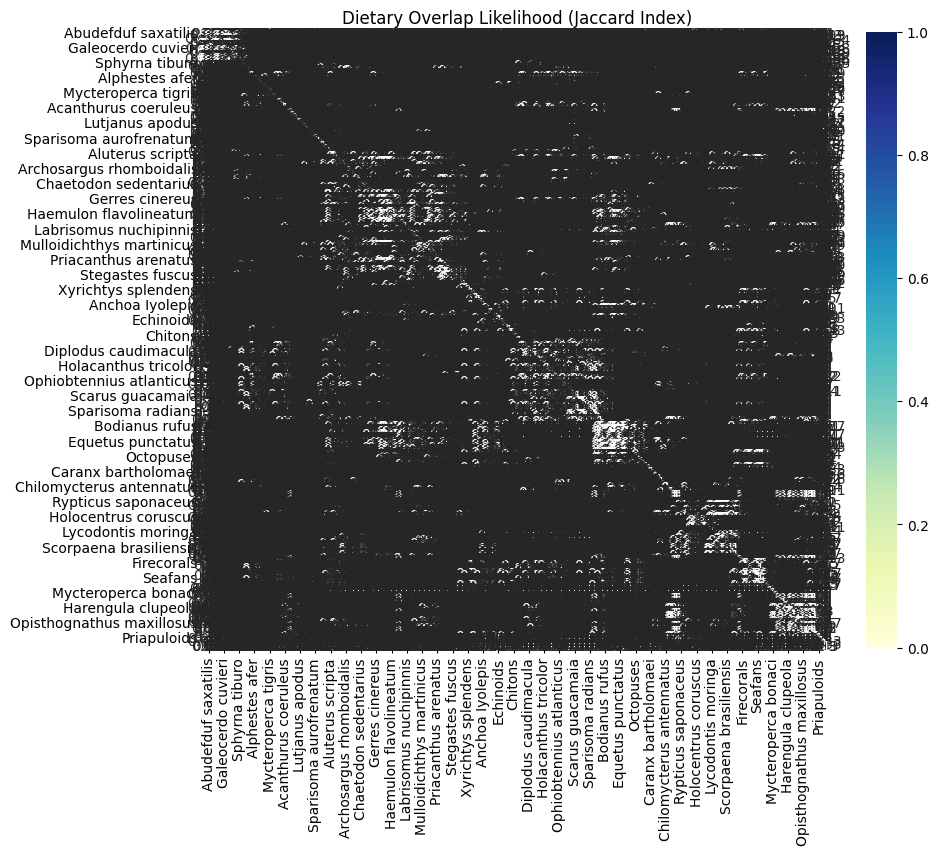

In [23]:
import seaborn as sns

# Get list of all predators (nodes with in-degree > 0)
preds = [n for n in G.nodes() if G.in_degree(n) > 0]
matrix_size = len(preds)
overlap_matrix = pd.DataFrame(index=preds, columns=preds, dtype=float)

total_overlaps = 0
total_pairs = 0

def jaccard_index(G, pred1, pred2):
    global total_overlaps, total_pairs
    
    prey1 = set(G.predecessors(pred1))
    prey2 = set(G.predecessors(pred2))
    
    if not prey1 and not prey2:
        return 0.0 # Both are likely basal species
        
    intersection = len(prey1.intersection(prey2))
    union = len(prey1.union(prey2))
    
    if pred1 != pred2:
        total_overlaps += intersection/union
        total_pairs += 1
    
    return intersection / union

for p1 in preds:
    for p2 in preds:
        overlap_matrix.loc[p1, p2] = jaccard_index(G, p1, p2)

print(f"Average Dietary Overlap (Jaccard Index) across all predator pairs: {total_overlaps/total_pairs:.4f}")

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(overlap_matrix, annot=True, cmap="YlGnBu")
plt.title("Dietary Overlap Likelihood (Jaccard Index)")
plt.show()


Tier 1 has 12 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.5435 in tier 1


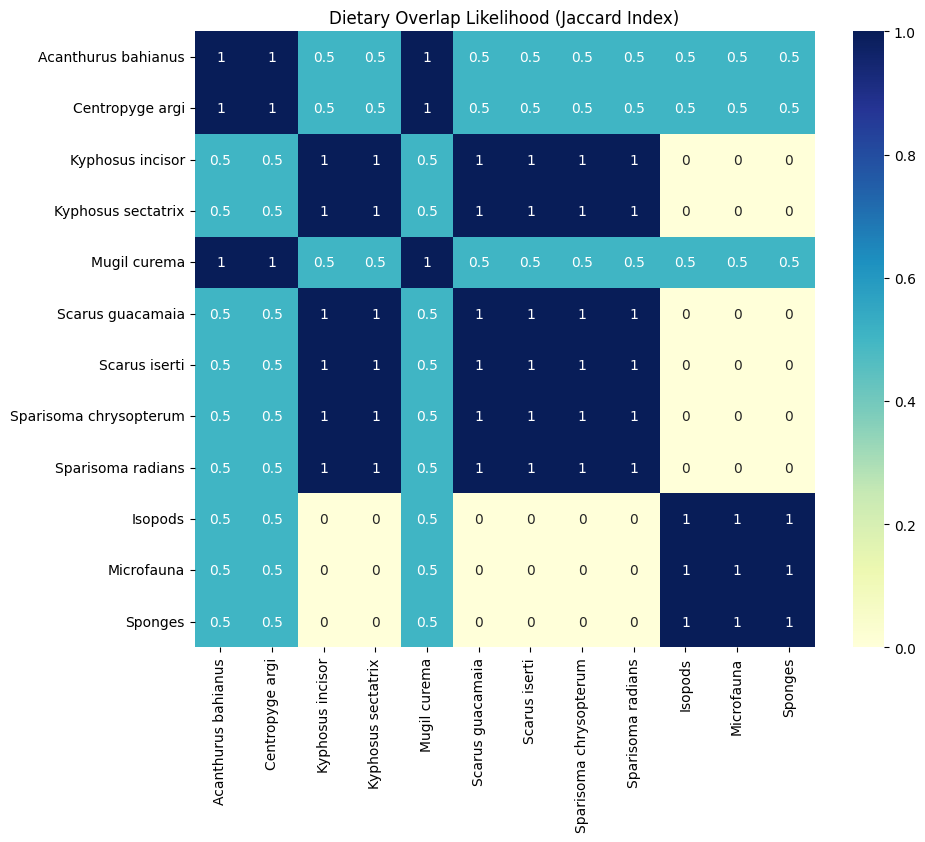


Tier 2 has 26 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.4356 in tier 2


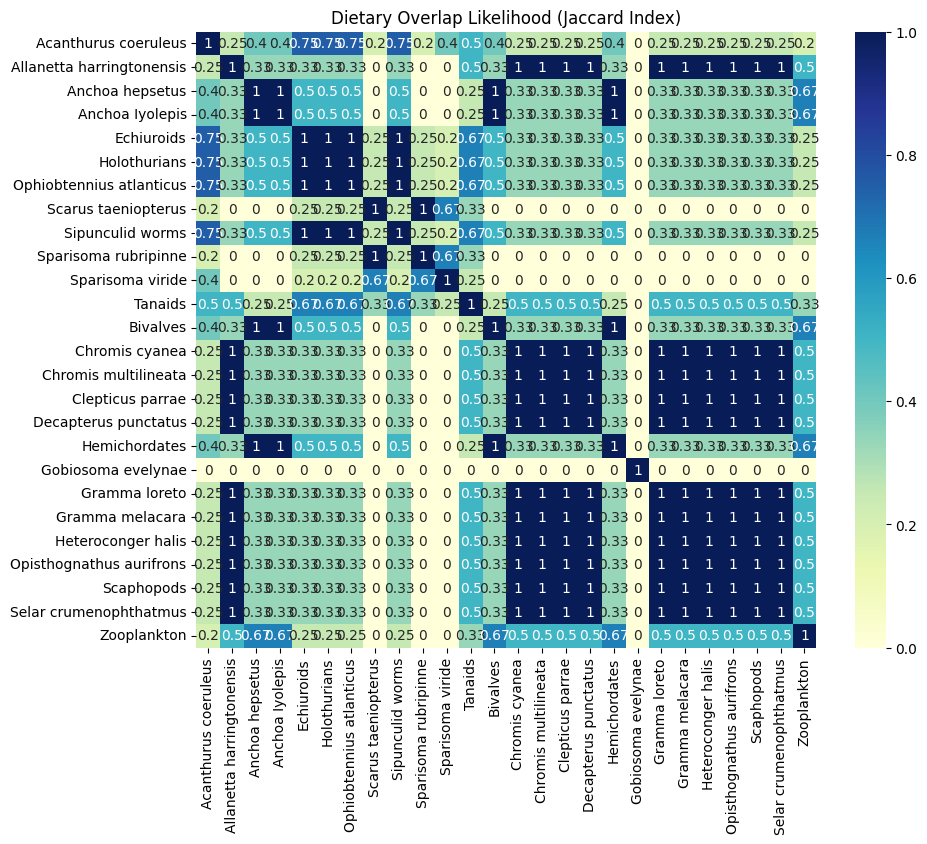


Tier 3 has 11 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.4955 in tier 3


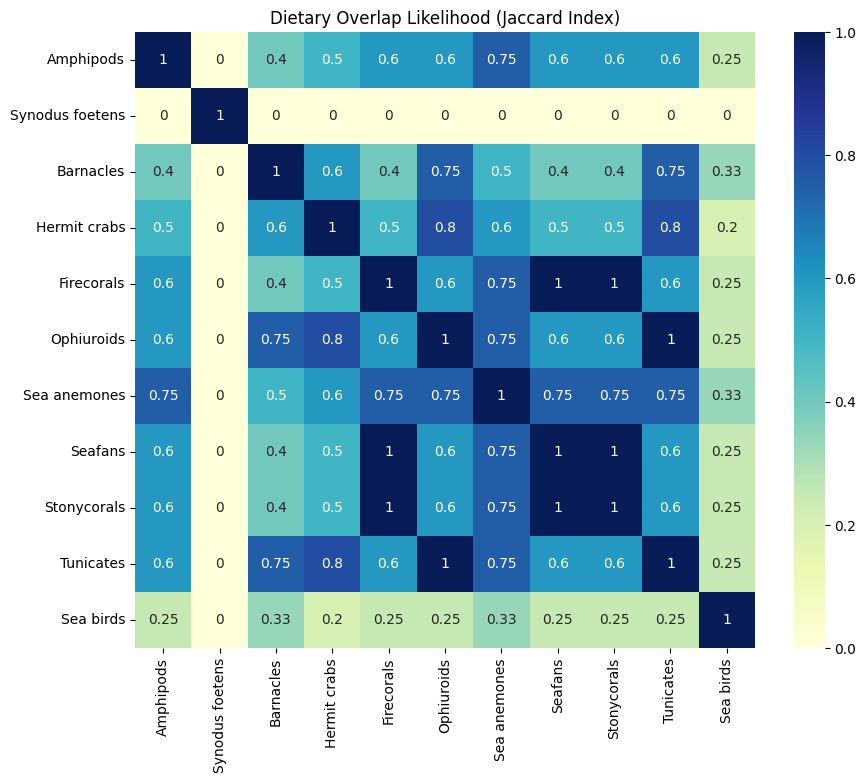


Tier 4 has 23 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.1873 in tier 4


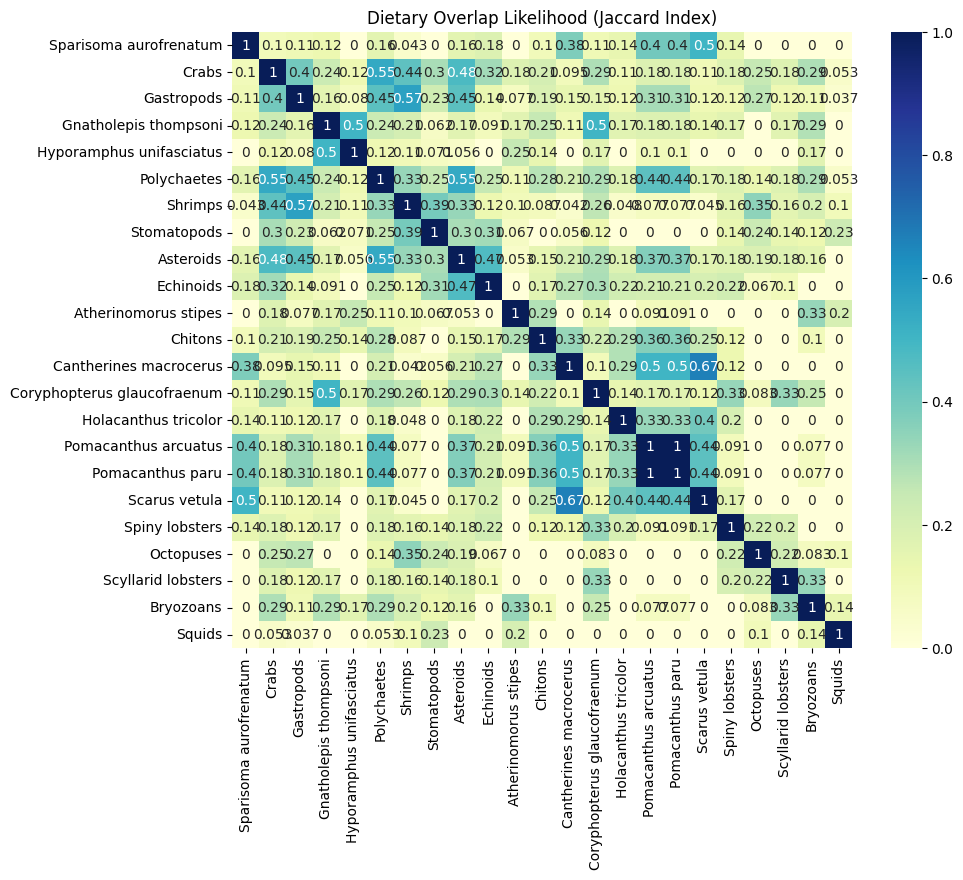


Tier 5 has 109 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.2066 in tier 5


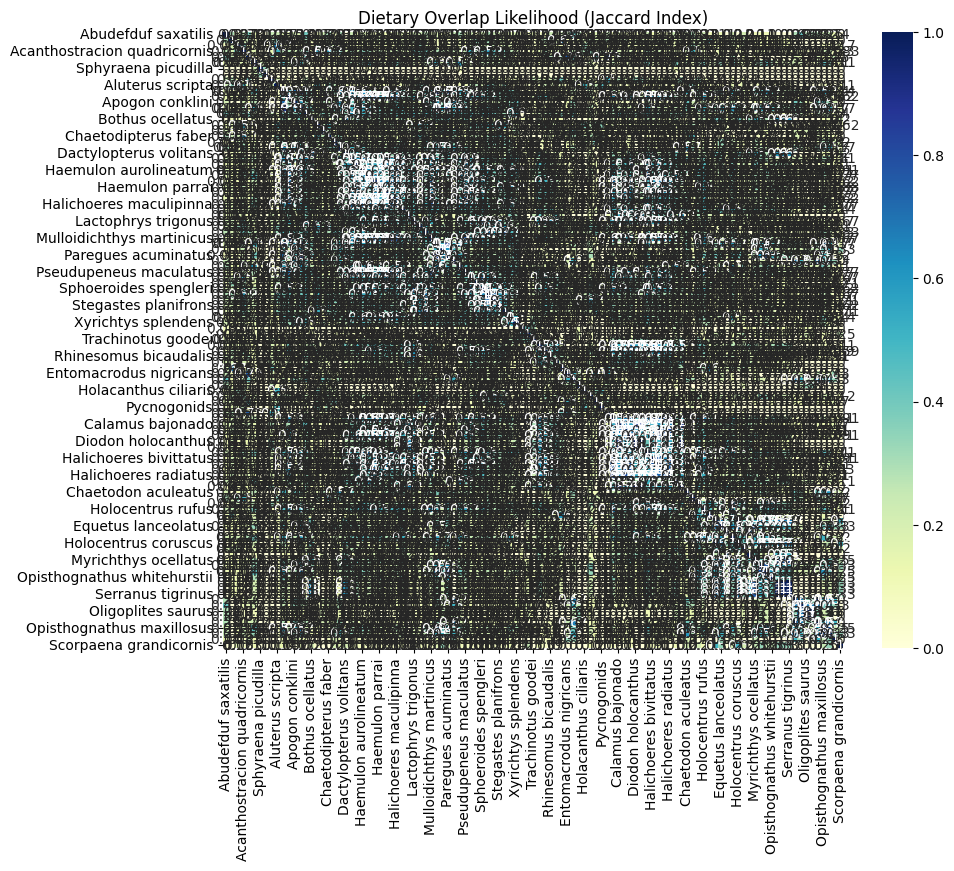


Tier 6 has 27 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.1235 in tier 6


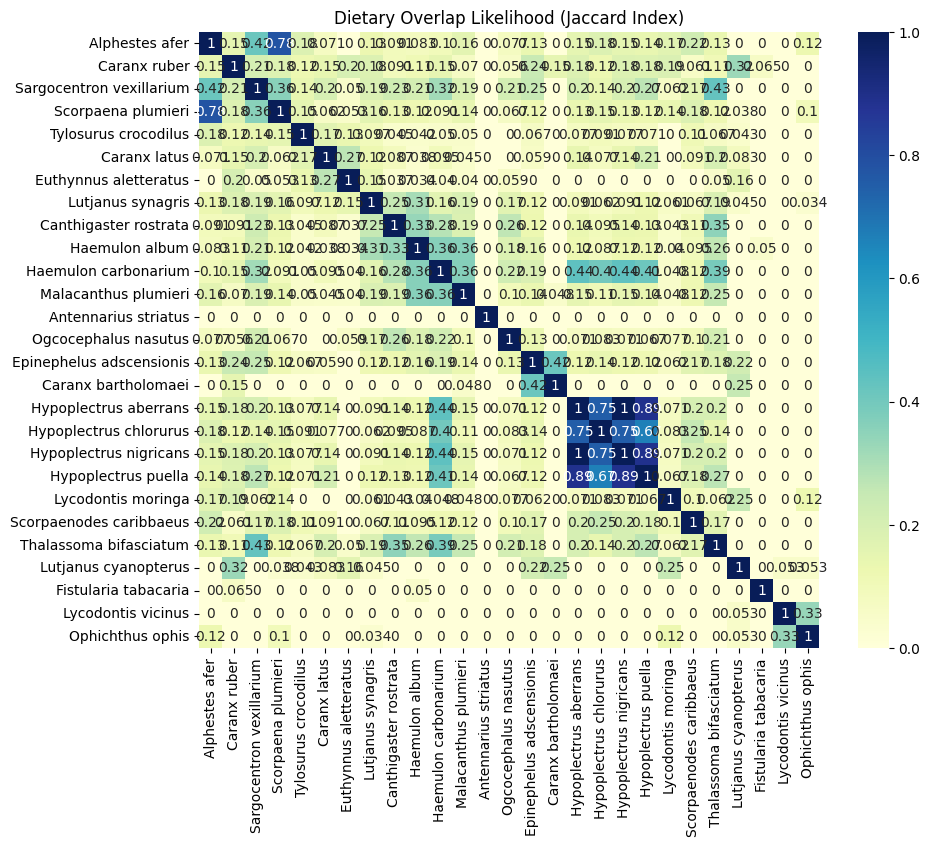


Tier 7 has 9 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.1377 in tier 7


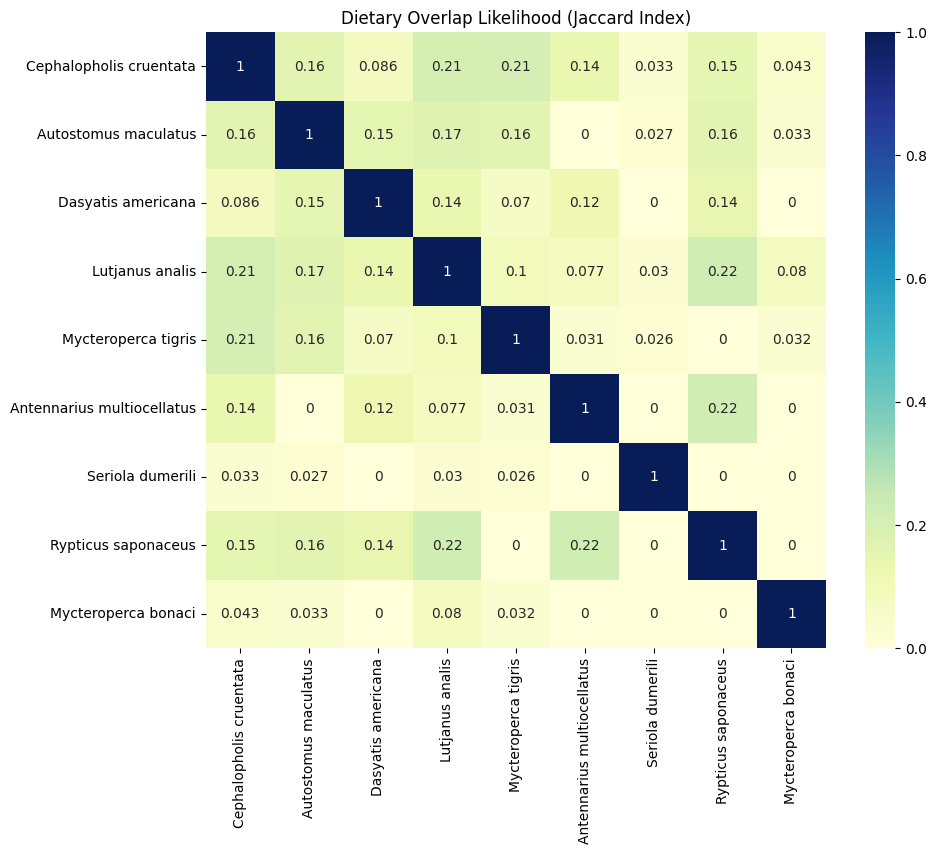


Tier 8 has 6 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.1718 in tier 8


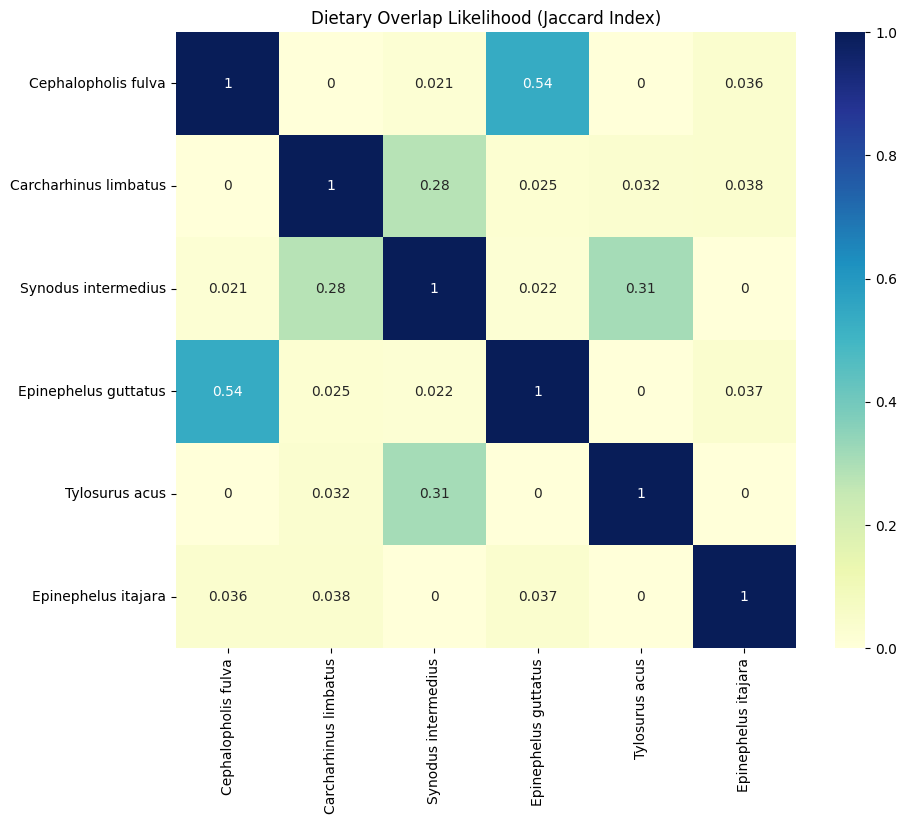


Tier 9 has 5 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.2835 in tier 9


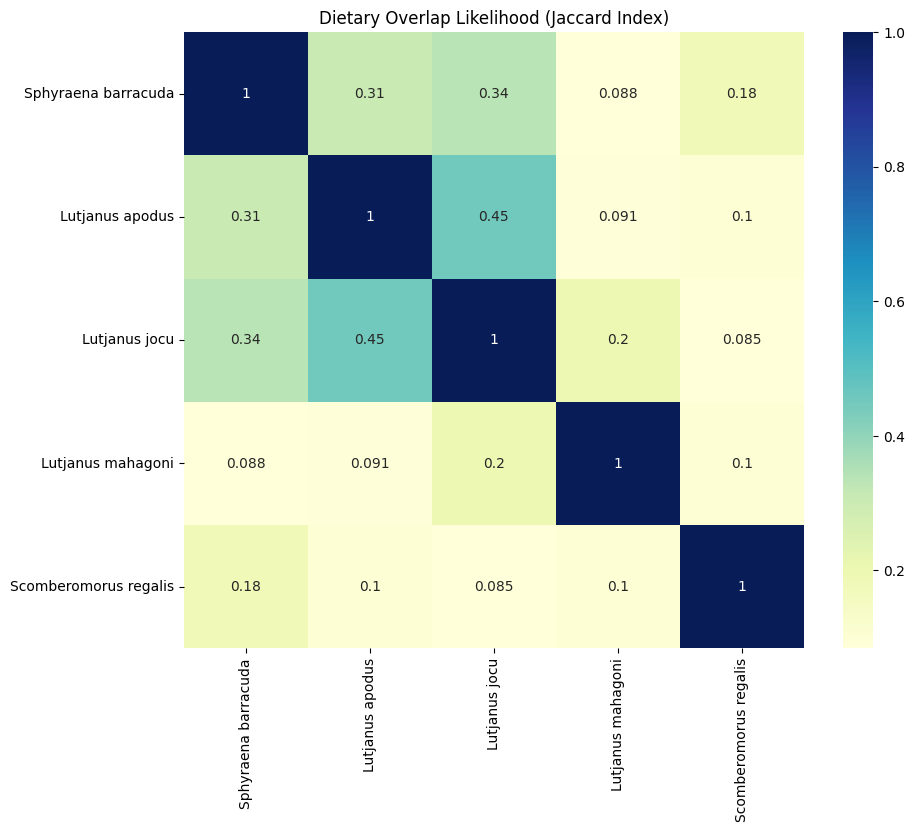


Tier 10 has 7 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.7458 in tier 10


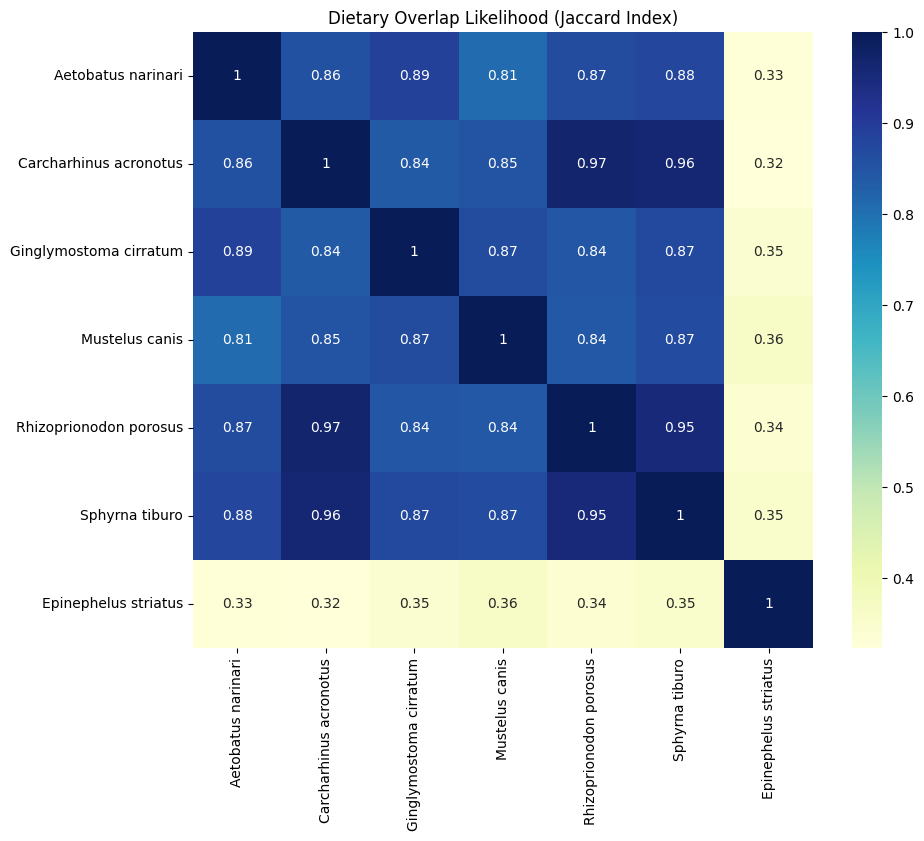


Tier 11 has 2 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.5132 in tier 11


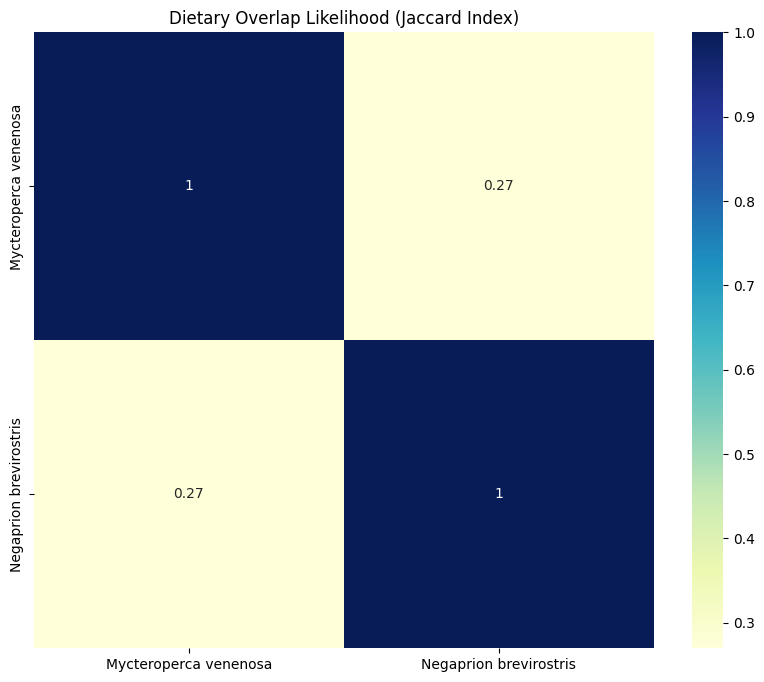


Tier 12 has 1 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 1.0000 in tier 12


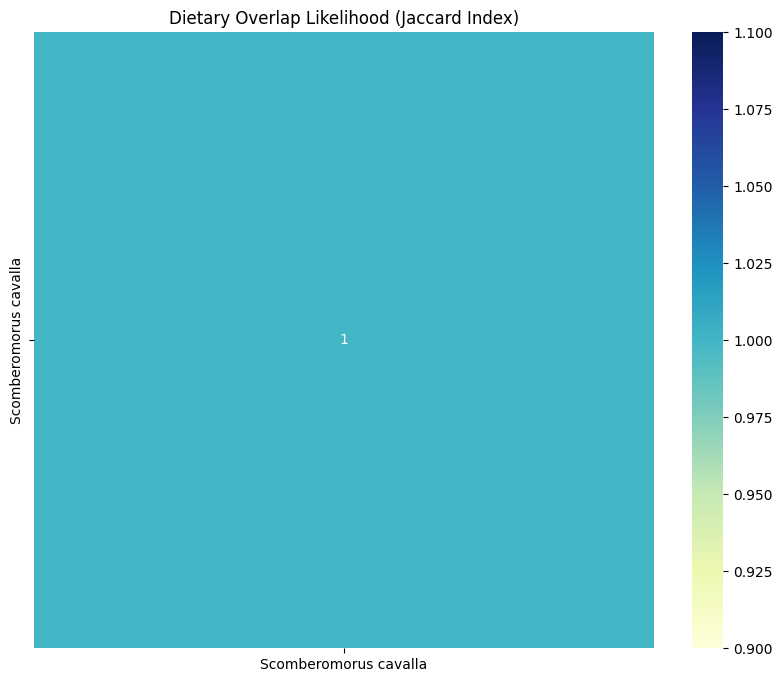


Tier 13 has 2 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.3733 in tier 13


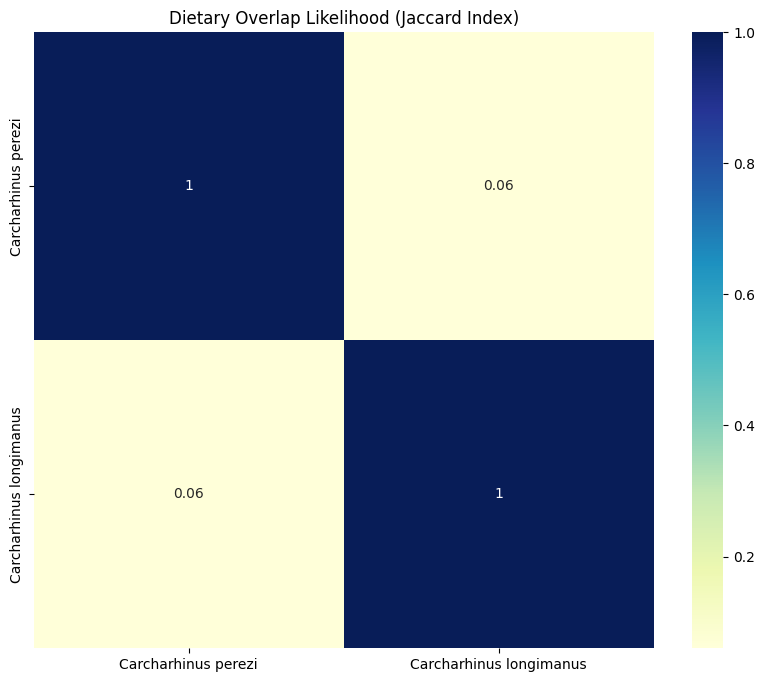


Tier 14 has 2 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.3882 in tier 14


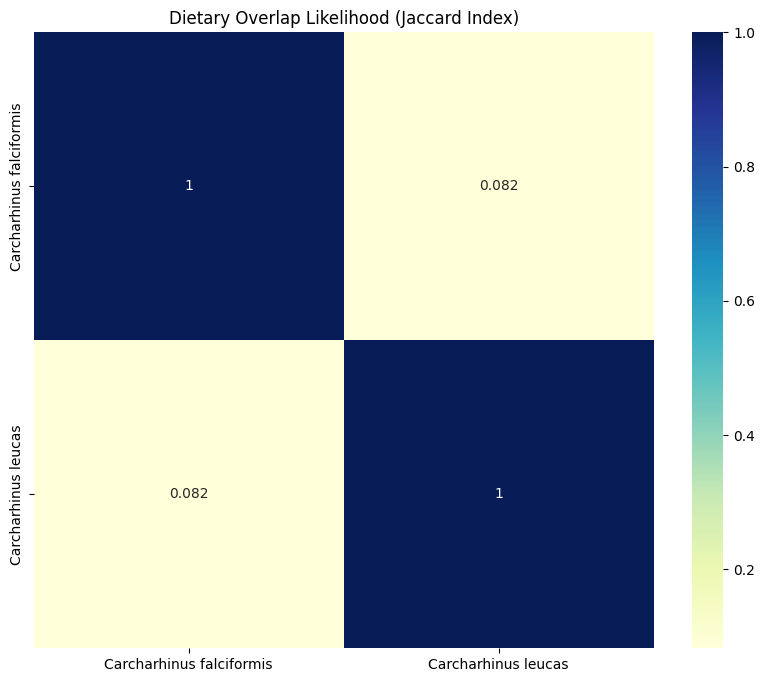


Tier 15 has 1 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 1.0000 in tier 15


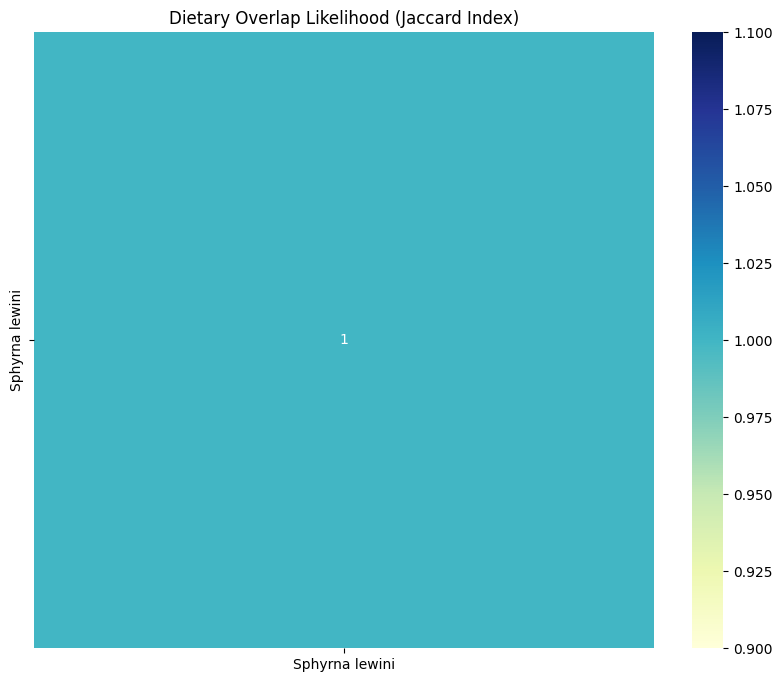


Tier 16 has 1 predators.
Average Dietary Overlap (Jaccard Index) across all predator pairs: 1.0000 in tier 16


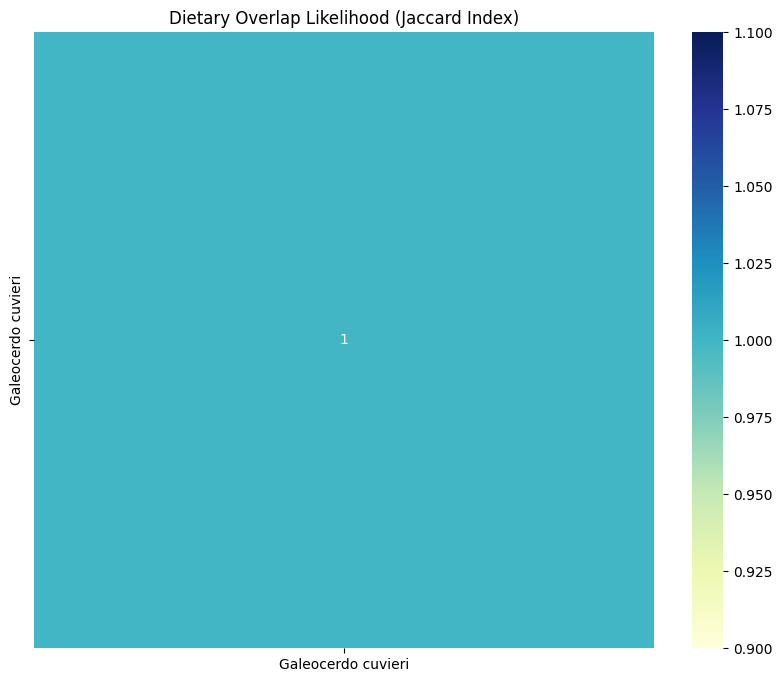

In [29]:
from collections import Counter

# Array of node levels for each node
node_levels = nx.get_node_attributes(G, 'level')

for tiers in sorted(set(node_levels.values())):
    if tiers != 0:
        preds = [n for n in G.nodes() if G.in_degree(n) > 0 and node_levels[n] == tiers]
        print(f"\nTier {tiers} has {len(preds)} predators.")
        matrix_size = len(preds)
        overlap_matrix = pd.DataFrame(index=preds, columns=preds, dtype=float)

        total_overlaps = 0
        total_pairs = 0
        
        for p1 in preds:
            for p2 in preds:
                j = jaccard_index(G, p1, p2)
                overlap_matrix.loc[p1, p2] = j
                total_overlaps += j
                total_pairs += 1
        
        print(f"Average Dietary Overlap (Jaccard Index) across all predator pairs: {total_overlaps/total_pairs:.4f} in tier {tiers}")

        # Plotting the heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(overlap_matrix, annot=True, cmap="YlGnBu")
        plt.title("Dietary Overlap Likelihood (Jaccard Index)")
        plt.show()